<a href="https://colab.research.google.com/github/Fahrizp24/PCVK_Ganjil_2025/blob/main/Pertemuan5_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

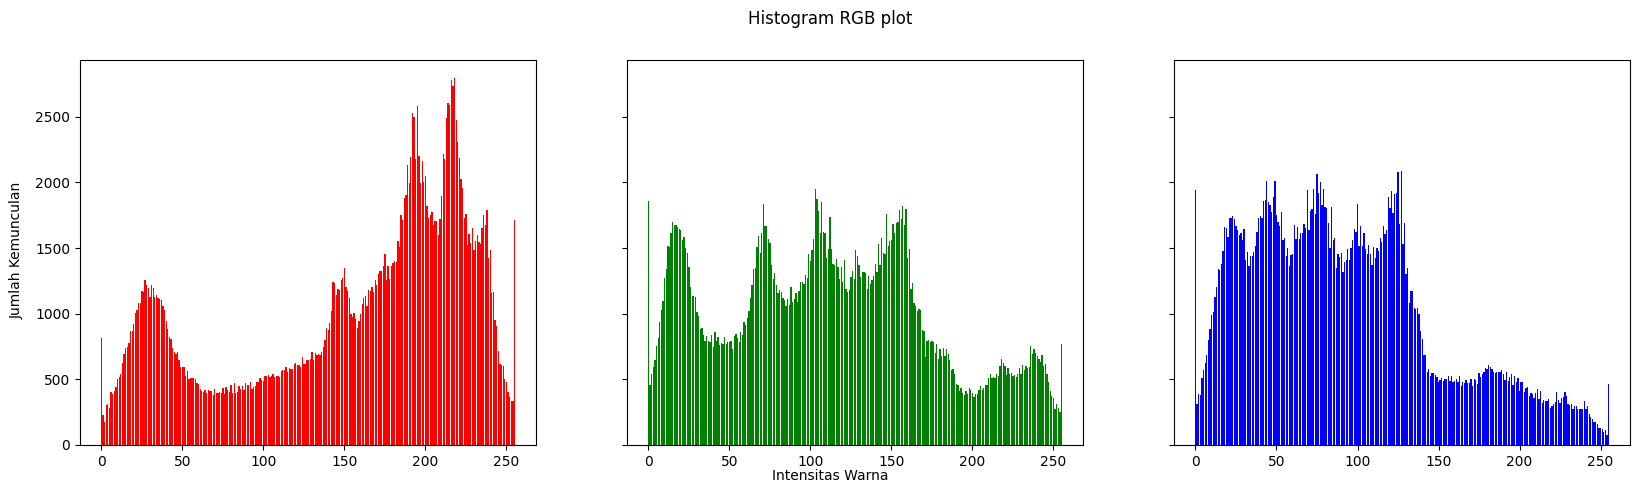

In [ ]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**PERTANYAAN PRAKTIKUM D1**

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

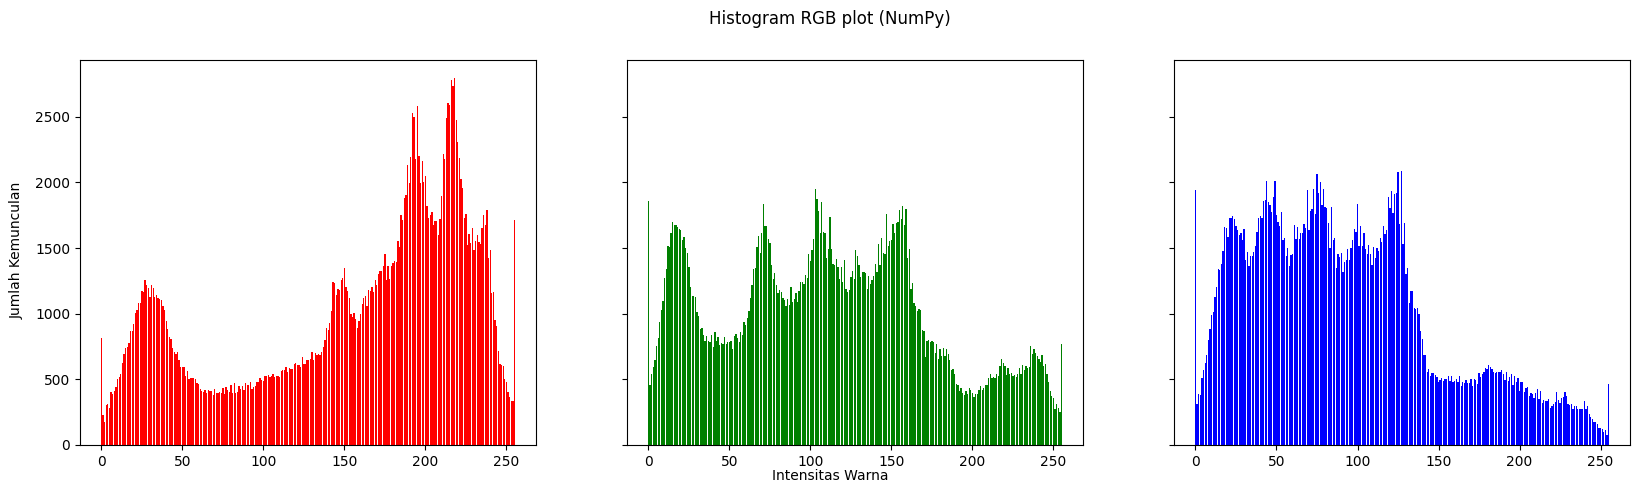

In [ ]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
# --- 1. Hitung Histogram Menggunakan NumPy ---
# Menghitung histogram untuk setiap channel warna (Merah, Hijau, Biru).
# img[:,:,0] -> Channel Merah
# .flatten() -> Mengubah array 2D menjadi 1D
# bins=256, range=[0,256] -> Menentukan ada 256 'keranjang' untuk intensitas 0 hingga 255
red_hist, red_bins = np.histogram(img[:,:,0].flatten(), bins=256, range=[0,256])
green_hist, green_bins = np.histogram(img[:,:,1].flatten(), bins=256, range=[0,256])
blue_hist, blue_bins = np.histogram(img[:,:,2].flatten(), bins=256, range=[0,256])

# --- 2. Siapkan dan Tampilkan Plot ---
# sharex=True dan sharey=True agar semua subplot memiliki skala sumbu yang sama.
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')

# Menambahkan label sumbu Y dan X untuk keseluruhan figure
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

# Menggambar bar plot untuk setiap histogram warna pada subplotnya masing-masing
# red_bins[:-1] digunakan karena np.histogram mengembalikan N+1 nilai tepi untuk N bins.
axs[0].bar(red_bins[:-1], red_hist, color='red')
axs[1].bar(green_bins[:-1], green_hist, color='green')
axs[2].bar(blue_bins[:-1], blue_hist, color='blue')

# Menampilkan plot ke layar
plt.show()


Outputnya sama antara histogram manual dengan libraary numpy

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

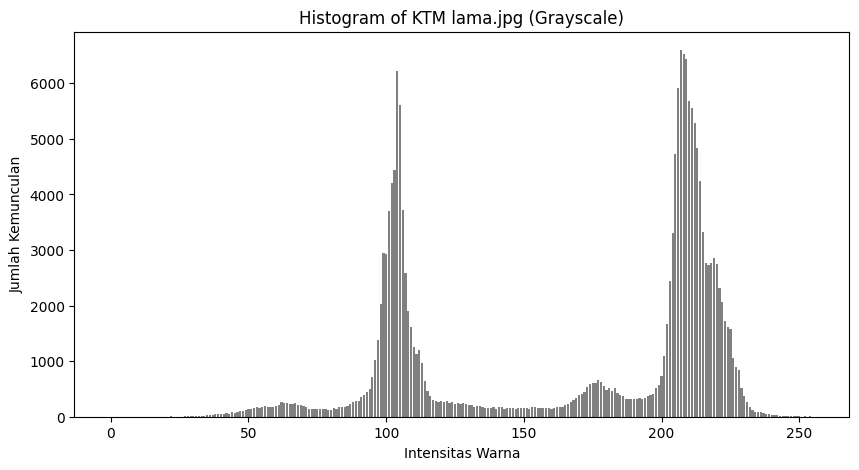

Rata Intensity: 167.7167641841041
distribusi intensitas rata.
Standard Deviation (Contrast): 53.441166558063955
image mempunyai kontras tinggi.


In [ ]:
img_ktm = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/ktm matahari.jpg')
img_ktm_gray = cv.cvtColor(img_ktm, cv.COLOR_BGR2GRAY)

# --- 2. Menghitung Histogram Gambar Grayscale ---
hist_ktm, bins_ktm = np.histogram(img_ktm_gray.flatten(), bins=256, range=[0,256])

# --- 3. Membuat dan Menampilkan Plot Histogram ---
plt.figure(figsize=[10,5])
plt.title('Histogram of KTM Matahari.jpg (Grayscale)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.bar(bins_ktm[:-1], hist_ktm, color='gray')
plt.show()

# --- 4. Menganalisis Distribusi Intensitas dan Kontras ---
rata_intensitas = np.mean(img_ktm_gray)
print(f"Rata Intensity: {rata_intensitas}")

if rata_intensitas < 85:
    print("Gambar gelap.")
elif rata_intensitas > 170:
    print("Gambar terang.")
else:
    print("distribusi intensitas rata.")

# Menganalisis standar deviasi untuk memperkirakan kontras gambar
std_intensity = np.std(img_ktm_gray)
print(f"Standard Deviation (Contrast): {std_intensity}")

if std_intensity < 50:
    print("image mempunyai kontras rendah.")
else:
    print("image mempunyai kontras tinggi.")

**D-2 PERCOBAAN HISTOGRAM EQUALIZATION**
1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan
flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)


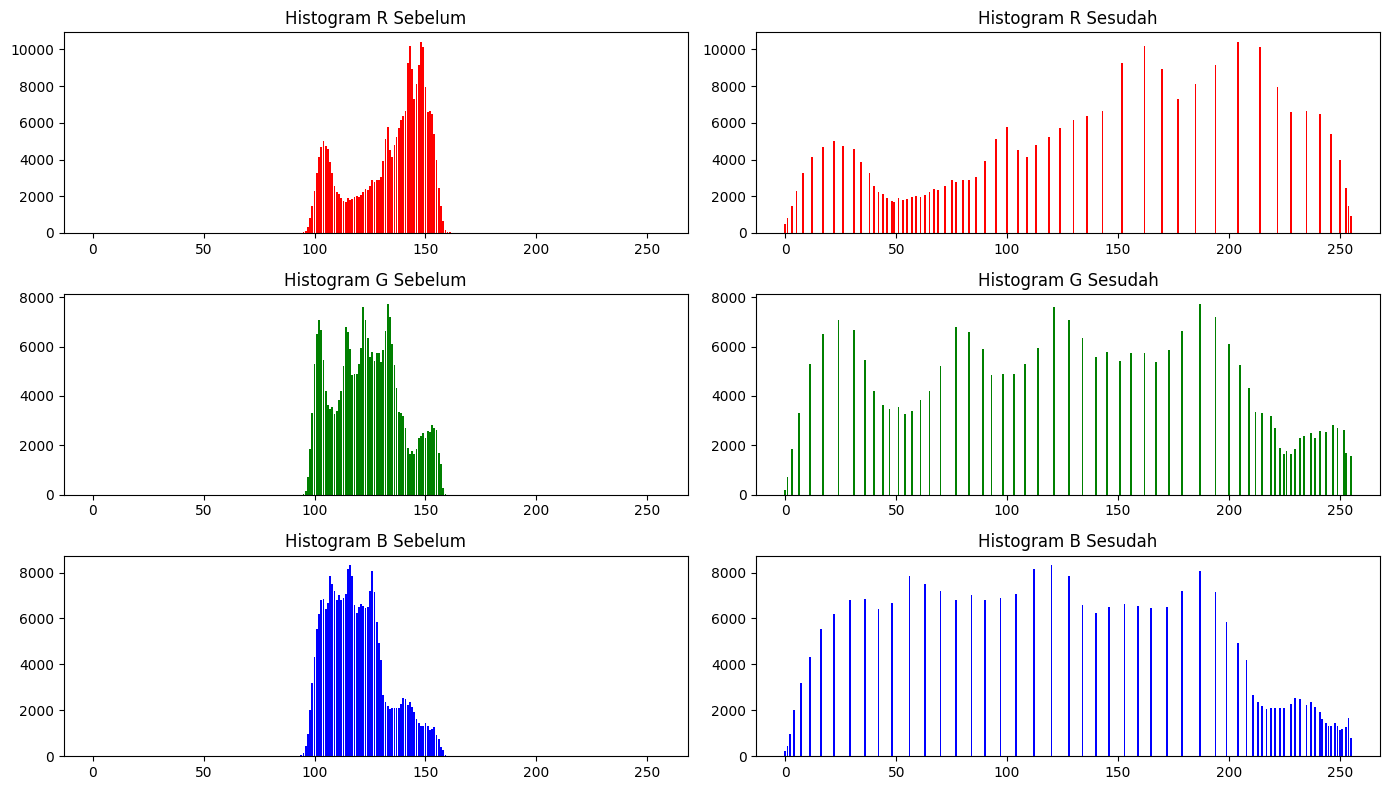

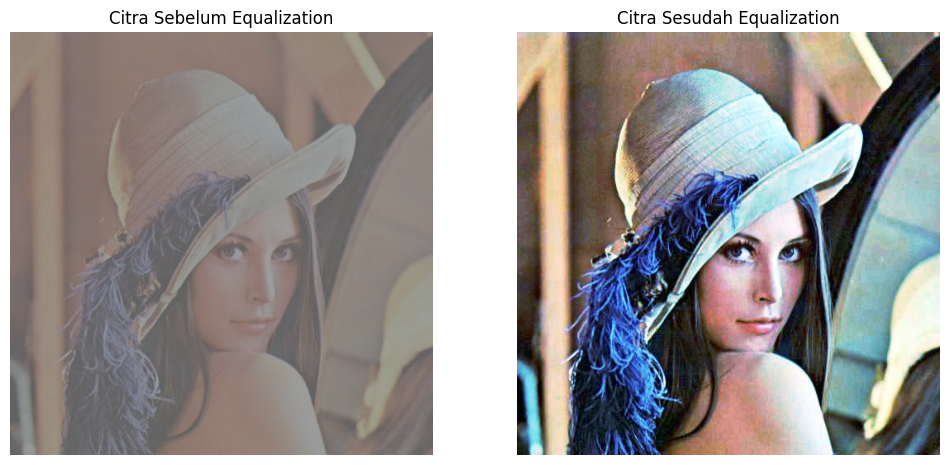

In [ ]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena_lc.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w, c = img.shape
total_pixels = h * w

# Function histogram equalization manual (sesuai flowchart)
def hist_equalization(channel):
    # 2. Hitung frekuensi
    hist, _ = np.histogram(channel.flatten(), bins=256, range=[0,256])

    # 3. Hitung kumulatif
    cdf = np.cumsum(hist)

    # 4. Normalisasi
    cdf_norm = cdf / float(total_pixels)

    # 5. Implementasi rumus Ko
    Ko = np.round(cdf_norm * 255).astype('uint8')

    # 6. Mapping pixel
    img_eq = Ko[channel]
    return img_eq, hist, np.histogram(img_eq.flatten(), bins=256, range=[0,256])[0]

# Pisah channel
r, g, b = cv.split(img_rgb)

# Equalisasi tiap channel manual
r_eq, r_hist_before, r_hist_after = hist_equalization(r)
g_eq, g_hist_before, g_hist_after = hist_equalization(g)
b_eq, b_hist_before, b_hist_after = hist_equalization(b)

# Gabungkan kembali
img_eq = cv.merge((r_eq, g_eq, b_eq))

# 7. Plot hasil
plt.figure(figsize=(14,8))

# Histogram sebelum
plt.subplot(3,2,1); plt.bar(range(256), r_hist_before, color='r'); plt.title("Histogram R Sebelum")
plt.subplot(3,2,3); plt.bar(range(256), g_hist_before, color='g'); plt.title("Histogram G Sebelum")
plt.subplot(3,2,5); plt.bar(range(256), b_hist_before, color='b'); plt.title("Histogram B Sebelum")

# Histogram sesudah
plt.subplot(3,2,2); plt.bar(range(256), r_hist_after, color='r'); plt.title("Histogram R Sesudah")
plt.subplot(3,2,4); plt.bar(range(256), g_hist_after, color='g'); plt.title("Histogram G Sesudah")
plt.subplot(3,2,6); plt.bar(range(256), b_hist_after, color='b'); plt.title("Histogram B Sesudah")

plt.tight_layout()
plt.show()

# Tampilkan gambar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Sebelum Equalization")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Sesudah Equalization")
plt.axis("off")

plt.show()


 2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.

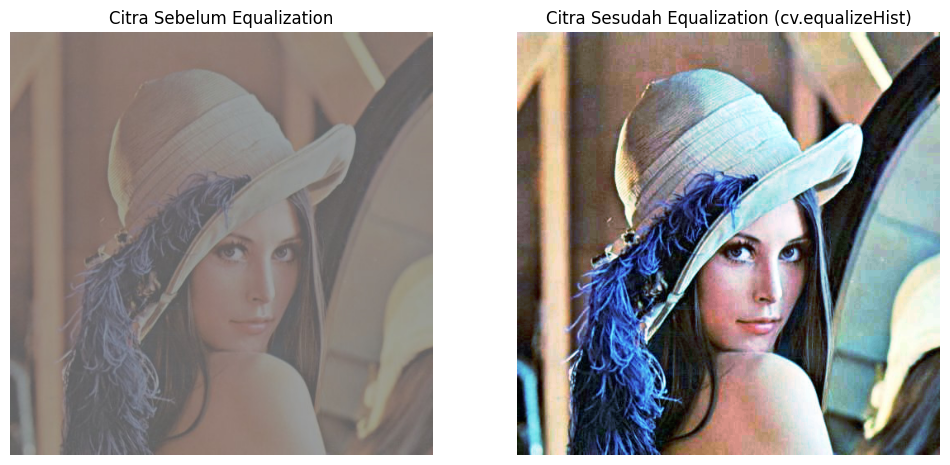

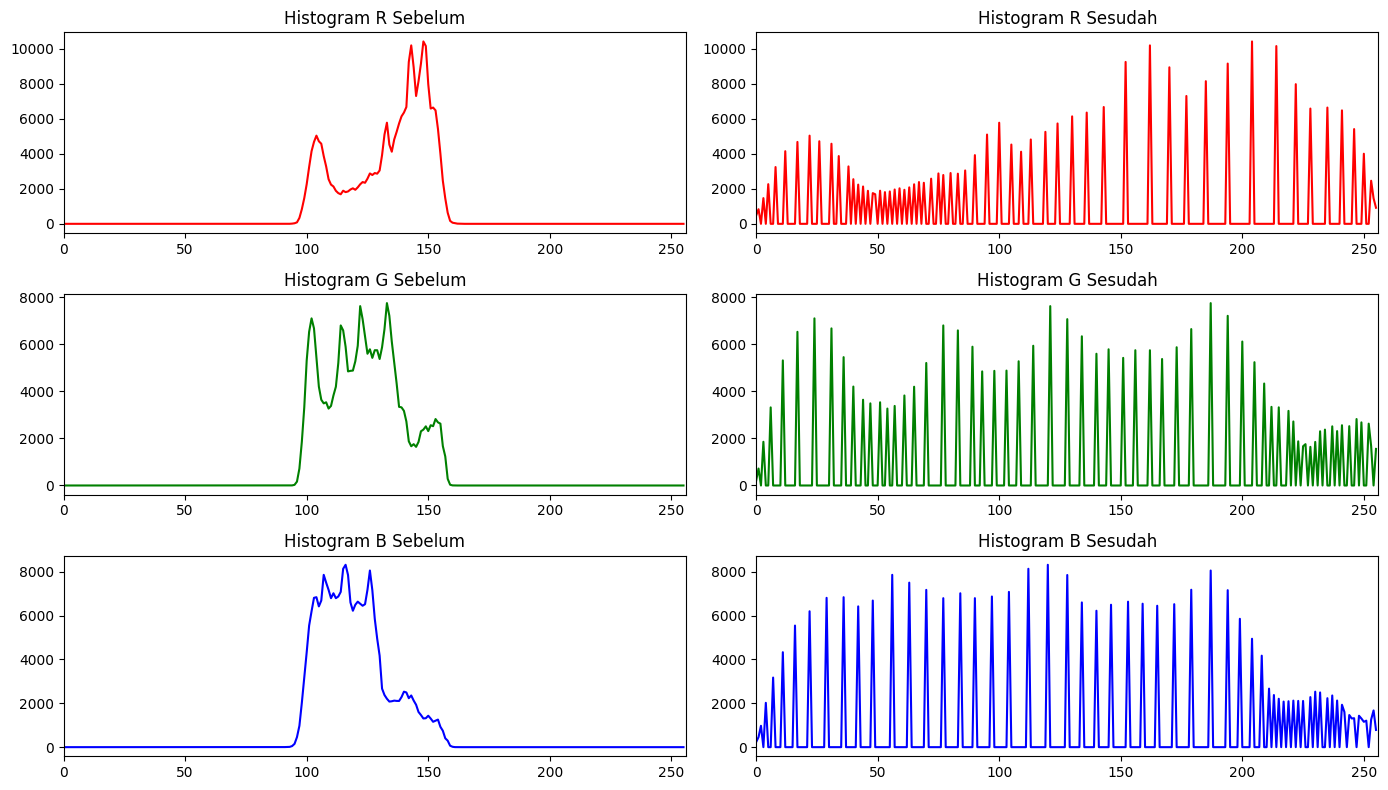

In [ ]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena_lc.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(img)

# Equalization tiap channel (pakai OpenCV)
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Merge kembali (ingat urutan matplotlib pakai RGB, bukan BGR)
img_eq = cv.merge((r_eq, g_eq, b_eq))

# --- Tampilkan gambar sebelum & sesudah ---
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Sebelum Equalization")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Sesudah Equalization (cv.equalizeHist)")
plt.axis("off")
plt.show()

# --- Histogram RGB sebelum & sesudah ---
color = ('r','g','b')
channels_before = cv.split(img_rgb)
channels_after  = cv.split(img_eq)

plt.figure(figsize=(14,8))
for i, col in enumerate(color):
    # Sebelum
    hist_before = cv.calcHist([channels_before[i]],[0],None,[256],[0,256])
    plt.subplot(3,2,2*i+1)
    plt.plot(hist_before, color=col)
    plt.title(f"Histogram {col.upper()} Sebelum")
    plt.xlim([0,256])

    # Sesudah
    hist_after = cv.calcHist([channels_after[i]],[0],None,[256],[0,256])
    plt.subplot(3,2,2*i+2)
    plt.plot(hist_after, color=col)
    plt.title(f"Histogram {col.upper()} Sesudah")
    plt.xlim([0,256])

plt.tight_layout()
plt.show()

Apakah output muncul sama?
jawab: Tidak, hasilnya tidak akan sama persis, meskipun kelihatannya mirip. Output mirip fungsi (kontras naik, histogram melebar), tapi tidak identik

**PERTANYAAN PRAKTIKUM D2**
1. Perbandingan Citra Lena

a. Gunakan hasil histogram equalization pada citra lena.jpg.

b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
visual citra? Apakah ada detail baru yang muncul setelah equalization?

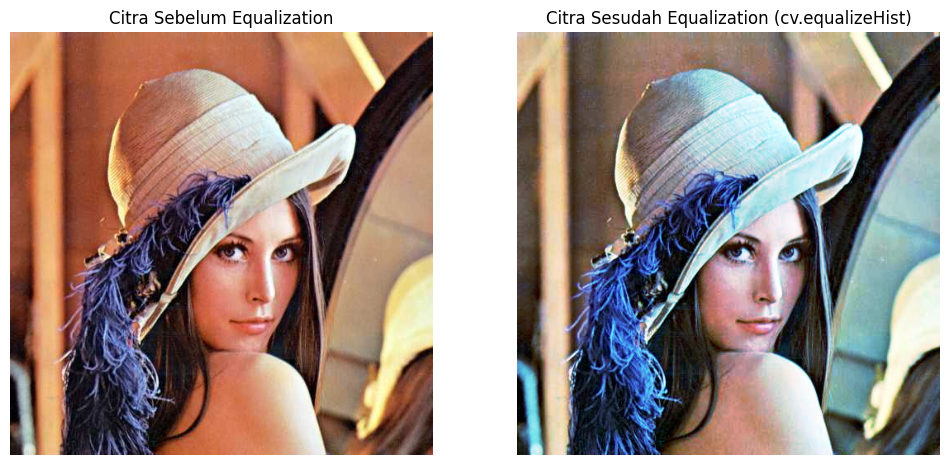

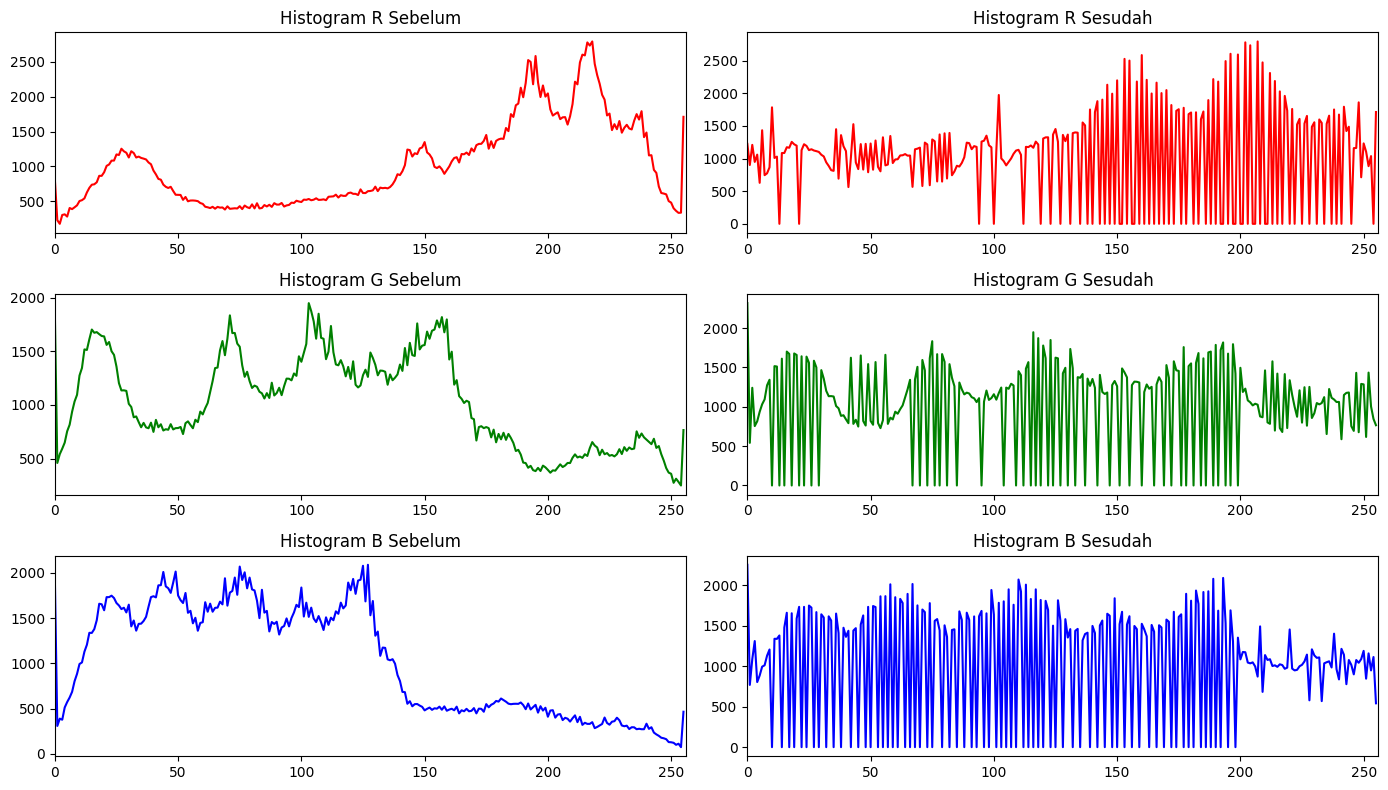

PSNR antara Lena asli dan hasil equalization: 17.948401486845302


In [ ]:
# Fungsi PSNR
def psnr(original, processed):
    mse = np.mean((original.astype(np.float64) - processed.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(img)

# Equalization tiap channel
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Merge kembali (urutan RGB biar sesuai matplotlib)
img_eq = cv.merge((r_eq, g_eq, b_eq))

# --- Tampilkan gambar sebelum & sesudah ---
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Sebelum Equalization")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Sesudah Equalization (cv.equalizeHist)")
plt.axis("off")
plt.show()

# --- Histogram RGB sebelum & sesudah ---
color = ('r','g','b')
channels_before = cv.split(img_rgb)
channels_after  = cv.split(img_eq)

plt.figure(figsize=(14,8))
for i, col in enumerate(color):
    # Sebelum
    hist_before = cv.calcHist([channels_before[i]],[0],None,[256],[0,256])
    plt.subplot(3,2,2*i+1)
    plt.plot(hist_before, color=col)
    plt.title(f"Histogram {col.upper()} Sebelum")
    plt.xlim([0,256])

    # Sesudah
    hist_after = cv.calcHist([channels_after[i]],[0],None,[256],[0,256])
    plt.subplot(3,2,2*i+2)
    plt.plot(hist_after, color=col)
    plt.title(f"Histogram {col.upper()} Sesudah")
    plt.xlim([0,256])

plt.tight_layout()
plt.show()

# --- Hitung PSNR ---
psnr_value = psnr(img_rgb, img_eq)
print("PSNR antara Lena asli dan hasil equalization:", psnr_value)


Biasanya nilai PSNR untuk histogram equalization ada di kisaran 20–30 dB. Nilai ini relatif tidak terlalu tinggi karena proses equalization memang mengubah distribusi warna cukup signifikan. Kualitas visual memang berubah citra jadi lebih kontras, detail di area gelap/terang lebih muncul, tapi warnanya bisa sedikit bergeser dari asli. Jadi ya, ada detail baru yang terlihat setelah equalization, khususnya di daerah rambut, topi, dan background yang sebelumnya terlalu gelap.

2. Gunakan Citra KTM Lama.jpg

a. Terapkan histogram equalization pada citra KTM lama.jpg.

b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang).

Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

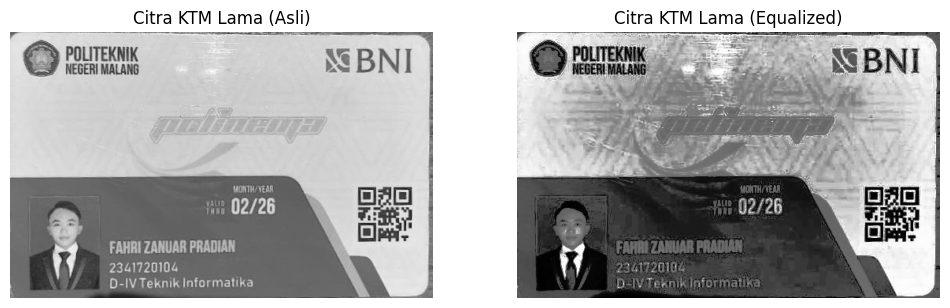

/tmp/ipython-input-3252653741.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(ktm.ravel(), 256, [0,256], color='gray')
/tmp/ipython-input-3252653741.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(ktm_eq.ravel(), 256, [0,256], color='black')


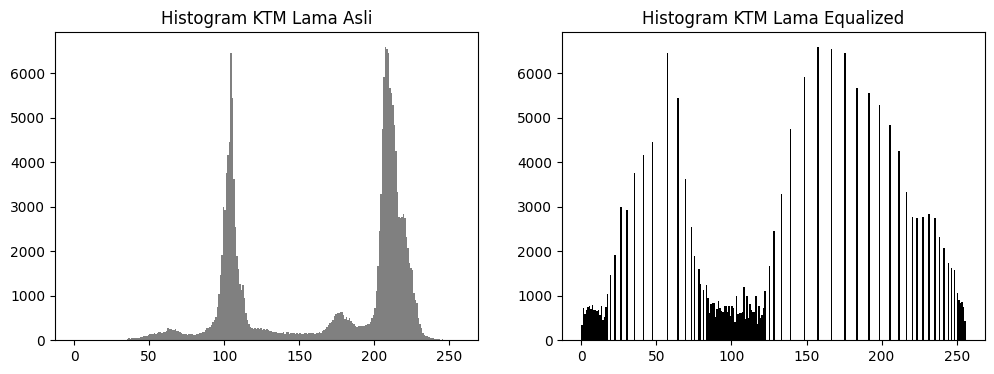

In [ ]:
# Baca citra KTM Lama
ktm = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK/images/ktm matahari.jpg", 0)   # langsung grayscale
ktm_eq = cv.equalizeHist(ktm)

# Plot gambar
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(ktm, cmap='gray')
plt.title("Citra KTM Lama (Asli)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ktm_eq, cmap='gray')
plt.title("Citra KTM Lama (Equalized)")
plt.axis("off")
plt.show()

# Plot histogram
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(ktm.ravel(), 256, [0,256], color='gray')
plt.title("Histogram KTM Lama Asli")

plt.subplot(1,2,2)
plt.hist(ktm_eq.ravel(), 256, [0,256], color='black')
plt.title("Histogram KTM Lama Equalized")
plt.show()


Histogram equalization memang meningkatkan kualitas informasi (teks lebih terbaca, wajah lebih jelas), tapi secara visual citra jadi lebih kasar dan kontrasnya tinggi. Jadi, untuk dokumen atau kartu identitas, hasil ini bermanfaat untuk menonjolkan informasi penting, tapi kurang cocok kalau ingin mempertahankan tampilan natural.

**D-3 TUGAS PRAKTIKUM DITHERING**
1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

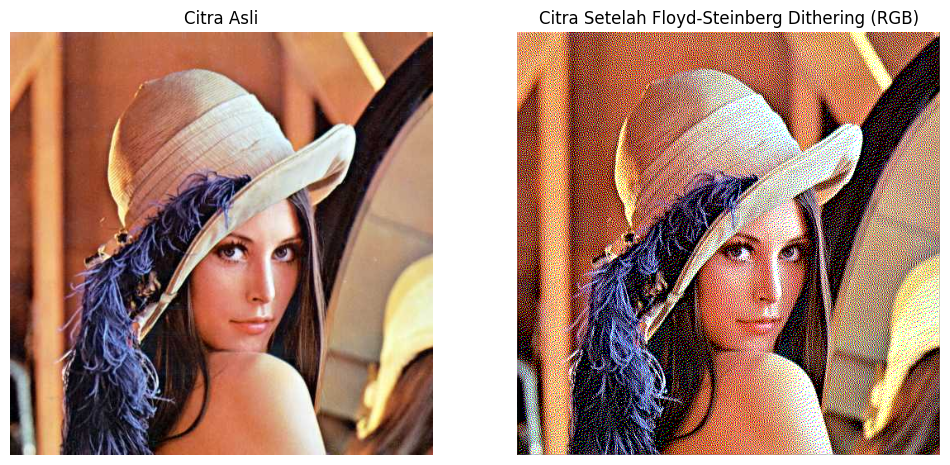

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca citra Lena
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float32)

# Floyd-Steinberg Dithering untuk RGB
h, w, c = img_rgb.shape
dithered = img_rgb.copy()

for y in range(h - 1):
    for x in range(1, w - 1):
        for ch in range(3):  # proses tiap channel
            old_pixel = dithered[y, x, ch]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke tetangga
            dithered[y    , x+1, ch] += error * 7/16
            dithered[y+1  , x-1, ch] += error * 3/16
            dithered[y+1  , x  , ch] += error * 5/16
            dithered[y+1  , x+1, ch] += error * 1/16

# Pastikan valid range 0–255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb.astype(np.uint8))
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dithered)
plt.title("Citra Setelah Floyd-Steinberg Dithering (RGB)")
plt.axis("off")
plt.show()


2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini

/tmp/ipython-input-2915272897.py:41: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256], color='gray')
/tmp/ipython-input-2915272897.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_eq.ravel(), 256, [0,256], color='black')


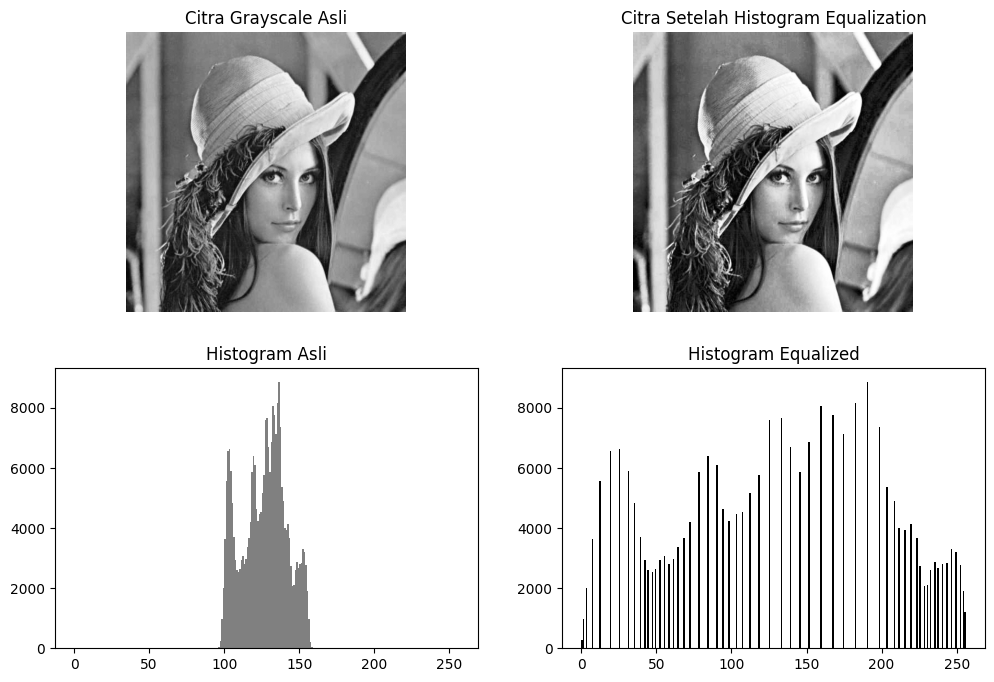

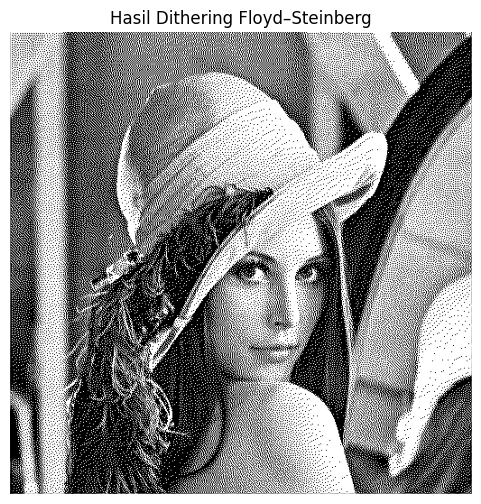

In [ ]:

# 1. Baca citra dan konversi ke grayscale
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena_lc.jpg", cv.IMREAD_GRAYSCALE)

# 2. Histogram Equalization
img_eq = cv.equalizeHist(img)

# 3. Floyd–Steinberg Dithering
h, w = img_eq.shape
dithered = img_eq.astype(np.float32).copy()

for y in range(h - 1):
    for x in range(1, w - 1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Sebarkan error ke tetangga
        dithered[y    , x+1] += error * 7/16
        dithered[y+1  , x-1] += error * 3/16
        dithered[y+1  , x  ] += error * 5/16
        dithered[y+1  , x+1] += error * 1/16

# 4. Normalisasi hasil
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# --- Tampilkan hasil ---
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Citra Grayscale Asli")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")

plt.subplot(2,2,3)
plt.hist(img.ravel(), 256, [0,256], color='gray')
plt.title("Histogram Asli")

plt.subplot(2,2,4)
plt.hist(img_eq.ravel(), 256, [0,256], color='black')
plt.title("Histogram Equalized")

plt.figure(figsize=(6,6))
plt.imshow(dithered, cmap='gray')
plt.title("Hasil Dithering Floyd–Steinberg")
plt.axis("off")
plt.show()


**Tugas praktikum mengubah dari RGB - grayscale - RGB`**

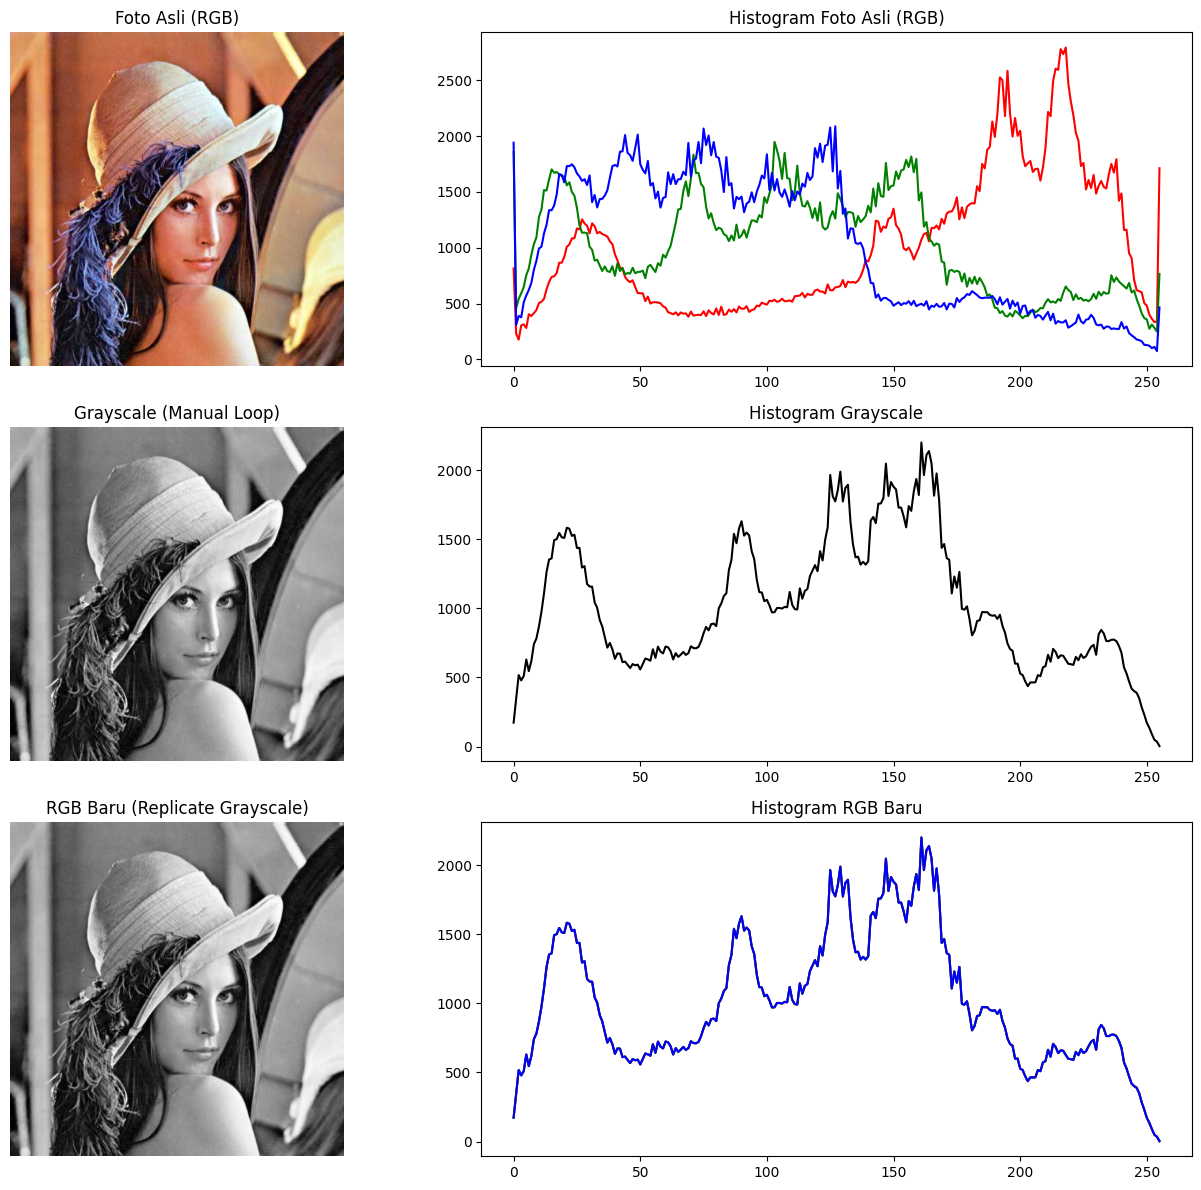

In [ ]:
img_lena = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK/images/lena.jpg")
img_lena_rgb = cv2.cvtColor(img_lena, cv2.COLOR_BGR2RGB)

img_lena_grayscale = np.zeros((img_lena_rgb.shape[0], img_lena_rgb.shape[1]), dtype=np.uint8)
for i in range(img_lena_rgb.shape[0]):
    for j in range(img_lena_rgb.shape[1]):
        R = img_lena_rgb[i, j, 0]
        G = img_lena_rgb[i, j, 1]
        B = img_lena_rgb[i, j, 2]
        gray_val = int(0.299 * R + 0.587 * G + 0.114 * B)
        img_lena_grayscale[i, j] = gray_val
rgb_simple = np.stack((img_lena_grayscale,)*3, axis=-1)

hist_r_orig, _ = np.histogram(img_lena_rgb[:,:,0].ravel(), bins=256, range=[0,256])
hist_g_orig, _ = np.histogram(img_lena_rgb[:,:,1].ravel(), bins=256, range=[0,256])
hist_b_orig, _ = np.histogram(img_lena_rgb[:,:,2].ravel(), bins=256, range=[0,256])

hist_gray, _ = np.histogram(img_lena_grayscale.ravel(), bins=256, range=[0,256])

hist_r_new, _ = np.histogram(rgb_simple[:,:,0].ravel(), bins=256, range=[0,256])
hist_g_new, _ = np.histogram(rgb_simple[:,:,1].ravel(), bins=256, range=[0,256])
hist_b_new, _ = np.histogram(rgb_simple[:,:,2].ravel(), bins=256, range=[0,256])

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0,0].imshow(img_lena_rgb)
axes[0,0].set_title("Foto Asli (RGB)")
axes[0,0].axis("off")

axes[0,1].plot(hist_r_orig, color="red")
axes[0,1].plot(hist_g_orig, color="green")
axes[0,1].plot(hist_b_orig, color="blue")
axes[0,1].set_title("Histogram Foto Asli (RGB)")

axes[1,0].imshow(img_lena_grayscale, cmap="gray")
axes[1,0].set_title("Grayscale (Manual Loop)")
axes[1,0].axis("off")

axes[1,1].plot(hist_gray, color="black")
axes[1,1].set_title("Histogram Grayscale")

axes[2,0].imshow(rgb_simple)
axes[2,0].set_title("RGB Baru (Replicate Grayscale)")
axes[2,0].axis("off")

axes[2,1].plot(hist_r_new, color="red")
axes[2,1].plot(hist_g_new, color="green")
axes[2,1].plot(hist_b_new, color="blue")
axes[2,1].set_title("Histogram RGB Baru")

plt.tight_layout()
plt.show()

Gambar tidak mengalami perubahan menjadi rgb kembali karena identitas foto terhapus ecara permanen saat diubah ke grayscale